# Loan Default Risk Analysis — Data Cleaning & Exploratory Data Analysis

**Dataset:** Lending Club Loan Data (396,030 loans, 2008–2016)
**Goal:** Clean the raw data and explore what drives loan default, ahead of building the SQL schema and Power BI dashboard.

**Sections:**
1. Load & Inspect Raw Data
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Key Insights Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 30)

## 1. Load & Inspect Raw Data

In [ ]:
df = pd.read_csv("../data/raw/lending_club_loan_two.csv")
print("Shape:", df.shape)
df.head()

Shape: (396030, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,Source Verified,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,Not Verified,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,Verified,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
mort_acc,37795,9.54
emp_title,22927,5.79
emp_length,18301,4.62
title,1756,0.44
pub_rec_bankruptcies,535,0.14
revol_util,276,0.07


**Observation:** `mort_acc`, `emp_title`, and `emp_length` have the most missing values. `loan_status` is our raw target — only `Fully Paid` and `Charged Off` categories are present, which is convenient (no ambiguous statuses like "Current" or "Late" to filter out).

In [5]:
df["loan_status"].value_counts()

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

## 2. Data Cleaning

Steps:
1. Create binary target `default_flag` from `loan_status`
2. Drop leaky / noisy / redundant columns
3. Handle missing values
4. Fix data types (term, emp_length, dates)

### 2.1 Create target variable
`loan_status` is text — we convert it to a binary column the model/analysis can use: `Charged Off` → 1 (default), `Fully Paid` → 0.

In [6]:
df["default_flag"] = df["loan_status"].map({"Charged Off": 1, "Fully Paid": 0})
df["default_flag"].value_counts(normalize=True).round(3)

default_flag
0    0.804
1    0.196
Name: proportion, dtype: float64

### 2.2 Drop unneeded columns
- `emp_title` — free text, 170k+ unique values, too noisy to use as-is
- `title` — duplicates the `purpose` column
- `address` — raw text, not usable as a feature
- `grade` — redundant, `sub_grade` already captures this at finer granularity
- `loan_status` — replaced by `default_flag`

In [7]:
cols_to_drop = ["emp_title", "title", "address", "grade", "loan_status"]
df = df.drop(columns=cols_to_drop)
print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (396030, 23)


### 2.3 Handle missing values
- `mort_acc`: impute using the median `mort_acc` **within each `total_acc` group** (the two are correlated, so this beats a flat median)
- `emp_length`: keep missing as an explicit `"Unknown"` category (handled again below when we convert it to a number)
- `revol_util`, `pub_rec_bankruptcies`: drop the small number of rows missing these (<1% combined)

In [8]:
total_acc_median = df.groupby("total_acc")["mort_acc"].transform("median")
df["mort_acc"] = df["mort_acc"].fillna(total_acc_median)
df["mort_acc"] = df["mort_acc"].fillna(df["mort_acc"].median())  # fallback for rare groups

df["emp_length"] = df["emp_length"].fillna("Unknown")

before = len(df)
df = df.dropna(subset=["revol_util", "pub_rec_bankruptcies"])
print(f"Dropped {before - len(df)} rows with missing revol_util/pub_rec_bankruptcies")
print("\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dropped 811 rows with missing revol_util/pub_rec_bankruptcies

Remaining nulls:


Series([], dtype: int64)


### 2.4 Fix data types
- `term`: `" 36 months"` (text) → `36` (int)
- `emp_length`: convert to an ordinal number of years; rows that were `"Unknown"` get flagged in a separate column and imputed with the median so no `NaN`s remain
- `issue_d`, `earliest_cr_line`: parse to proper datetime

In [9]:
df["term"] = df["term"].str.strip().str.replace(" months", "", regex=False).astype(int)

emp_length_map = {
    "Unknown": np.nan, "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
    "4 years": 4, "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8,
    "9 years": 9, "10+ years": 10,
}
df["emp_length_years"] = df["emp_length"].map(emp_length_map)
df["emp_length_unknown"] = df["emp_length_years"].isna().astype(int)
df["emp_length_years"] = df["emp_length_years"].fillna(df["emp_length_years"].median())
df = df.drop(columns=["emp_length"])

df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y")

df[["term", "emp_length_years", "emp_length_unknown", "issue_d", "earliest_cr_line"]].head()

,term,emp_length_years,emp_length_unknown,issue_d,earliest_cr_line
0,36,10.0,0,2015-01-01,1990-06-01
1,36,4.0,0,2015-01-01,2004-07-01
2,36,0.0,0,2015-01-01,2007-08-01
3,36,6.0,0,2014-11-01,2006-09-01
4,60,9.0,0,2013-04-01,1999-03-01


## 3. Feature Engineering

- `credit_history_years`: how long the borrower had credit history at the time the loan was issued
- `loan_to_income`: loan amount relative to annual income — a common risk ratio

In [10]:
df["credit_history_years"] = ((df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25).round(1)
df["loan_to_income"] = (df["loan_amnt"] / df["annual_inc"]).round(3)

print("Final shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())
df.to_csv("../data/processed/loan_cleaned.csv", index=False)
print("Saved to data/processed/loan_cleaned.csv")

Final shape: (395219, 26)
Remaining nulls: 0


Saved to data/processed/loan_cleaned.csv


## 4. Exploratory Data Analysis

Now that the data is clean, let's answer the key business questions:
- What's the overall default rate?
- How does default risk vary by grade, purpose, and home ownership?
- Has default risk changed over time?
- Which numeric features correlate most with default?

In [11]:
default_rate = df["default_flag"].mean()
print(f"Overall default rate: {default_rate:.2%} ({df['default_flag'].sum():,} of {len(df):,} loans)")

Overall default rate: 19.62% (77,523 of 395,219 loans)


### 4.1 Default rate by sub-grade
Grade is Lending Club's own risk rating — we'd expect default rate to climb steadily from A1 (safest) to G5 (riskiest).

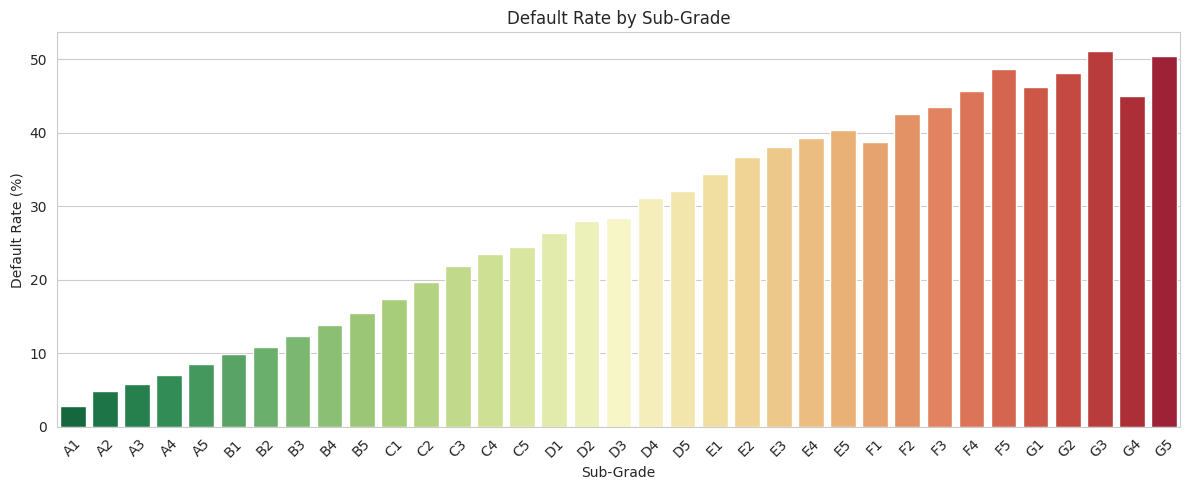

In [12]:
subgrade_default = df.groupby("sub_grade")["default_flag"].mean().sort_index() * 100

plt.figure(figsize=(12, 5))
sns.barplot(x=subgrade_default.index, y=subgrade_default.values, hue=subgrade_default.index,
            palette="RdYlGn_r", legend=False)
plt.title("Default Rate by Sub-Grade")
plt.ylabel("Default Rate (%)")
plt.xlabel("Sub-Grade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Default rate rises almost perfectly monotonically from A1 (~2.9%) to G3 (~51%) — confirms Lending Club's grading system is a strong, reliable risk signal.

### 4.2 Default rate by loan purpose

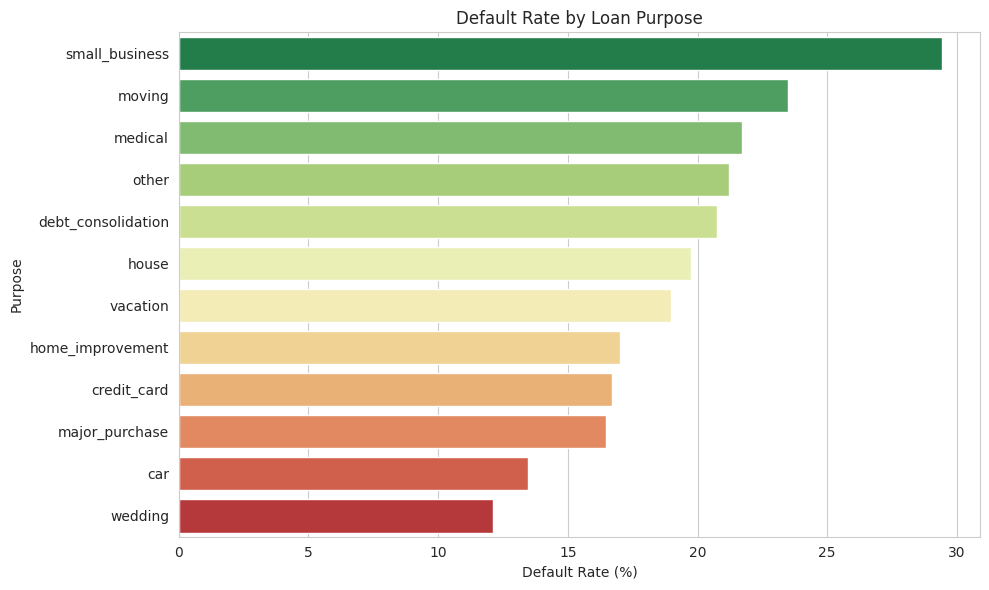

In [13]:
purpose_default = (
    df.groupby("purpose")["default_flag"]
    .agg(["mean", "count"])
    .query("count >= 500")
    .sort_values("mean", ascending=False)
)
purpose_default["mean"] = purpose_default["mean"] * 100

plt.figure(figsize=(10, 6))
sns.barplot(y=purpose_default.index, x=purpose_default["mean"], hue=purpose_default.index,
            palette="RdYlGn_r", legend=False)
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Purpose")
plt.tight_layout()
plt.show()

**Insight:** `small_business` loans default the most (~29%) — likely due to unpredictable cash flow. `wedding` and `car` loans are safest (~12–13%).

### 4.3 Default rate by home ownership

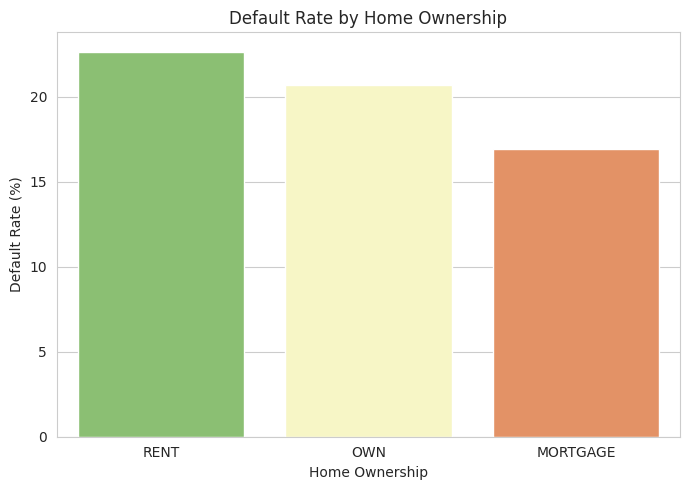

In [14]:
home_default = df.groupby("home_ownership")["default_flag"].agg(["mean", "count"]).query("count >= 500")
home_default["mean"] = home_default["mean"] * 100
home_default = home_default.sort_values("mean", ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=home_default.index, y=home_default["mean"], hue=home_default.index,
            palette="RdYlGn_r", legend=False)
plt.title("Default Rate by Home Ownership")
plt.ylabel("Default Rate (%)")
plt.xlabel("Home Ownership")
plt.tight_layout()
plt.show()

**Insight:** Renters default more (22.7%) than mortgage holders (17.0%) — owning property (even with a mortgage) correlates with financial stability.

### 4.4 Default rate over time

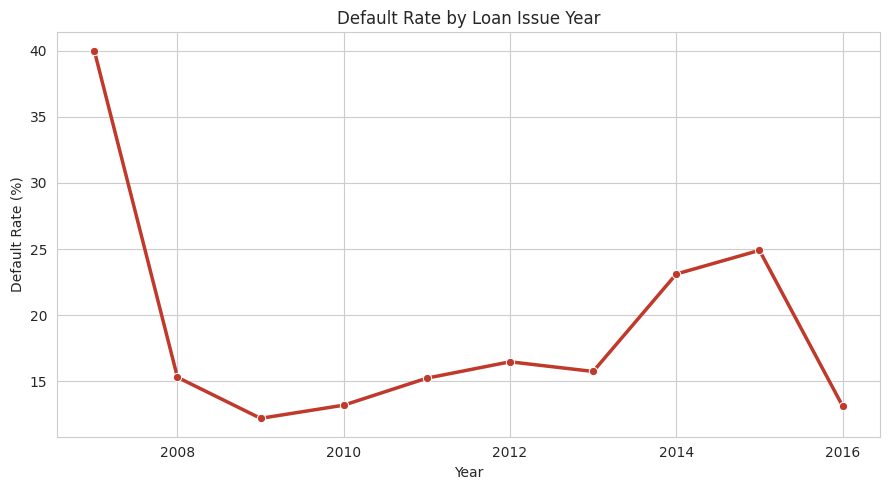

In [15]:
df["issue_year"] = df["issue_d"].dt.year
year_default = df.groupby("issue_year")["default_flag"].agg(["mean", "count"])
year_default["mean"] = year_default["mean"] * 100

plt.figure(figsize=(9, 5))
sns.lineplot(x=year_default.index, y=year_default["mean"], marker="o", linewidth=2.5, color="#c0392b")
plt.title("Default Rate by Loan Issue Year")
plt.ylabel("Default Rate (%)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

**Insight:** Default rate spiked in 2014–2015 (23–25%) compared to 2009–2013 (~13–16%) — consistent with Lending Club's rapid loan-volume growth phase and looser underwriting at the time.

### 4.5 Correlation of numeric features with default

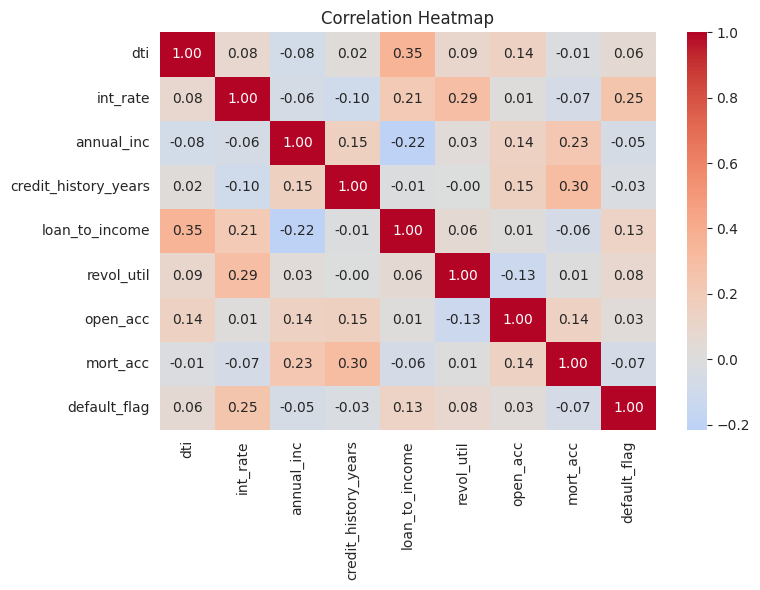

In [16]:
numeric_cols = ["dti", "int_rate", "annual_inc", "credit_history_years",
                "loan_to_income", "revol_util", "open_acc", "mort_acc", "default_flag"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Insight:** `int_rate` is the strongest numeric correlate with default (0.25) — makes sense since interest rate is itself set based on perceived risk (grade). `loan_to_income` (0.13) is the next most relevant engineered feature.

## 5. Key Insights Summary

| Finding | Detail |
|---|---|
| Overall default rate | 19.6% |
| Strongest risk signal | Sub-grade (2.9% for A1 → 51% for G3) |
| Riskiest loan purpose | Small business (29.4%) |
| Safest loan purpose | Wedding (12.1%) |
| Home ownership effect | Renters (22.7%) riskier than mortgage holders (17.0%) |
| Time trend | Default rate spiked in 2014–2015 |
| Top numeric correlate | Interest rate (0.25) |

**Next steps:** Load `loan_cleaned.csv` into a PostgreSQL star schema, then build the Power BI risk dashboard using these same segments (grade, purpose, home ownership, year).